# Global Food Crisis Analysis - Data Processing

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
BASE_PATH = os.path.expanduser("~/Desktop/DCU/SUBJECTS/Data Management & Visualization/Assignment/Food_Crisis_Project")
RAW_DATA_PATH = os.path.join(BASE_PATH, "Raw_Data")
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "Processed_Data")

print(f"Base path: {BASE_PATH}")
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Processed data path: {PROCESSED_DATA_PATH}")

Base path: /Users/robert/Desktop/DCU/SUBJECTS/Data Management & Visualization/Assignment/Food_Crisis_Project
Raw data path: /Users/robert/Desktop/DCU/SUBJECTS/Data Management & Visualization/Assignment/Food_Crisis_Project/Raw_Data
Processed data path: /Users/robert/Desktop/DCU/SUBJECTS/Data Management & Visualization/Assignment/Food_Crisis_Project/Processed_Data


In [4]:
# Loading WFP Data 
wfp_files = [
    'wfp_2019.csv',
    'wfp_2020.csv',
    'wfp_2021.csv',
    'wfp_2022.csv',
    'wfp_2023.csv',
    'wfp_2024.csv',
    'wfp_2025.csv'
]

wfp_data_list = []

for file in wfp_files:
    file_path = os.path.join(RAW_DATA_PATH, "WFP", file)
    print(f"Loading {file}...")
    df = pd.read_csv(file_path)
    wfp_data_list.append(df)
    print(f"  Rows: {len(df):,}")

wfp_combined = pd.concat(wfp_data_list, ignore_index=True)
print(f"\nTotal WFP records: {len(wfp_combined):,}")
print(f"Columns: {list(wfp_combined.columns)}")

Loading wfp_2019.csv...
  Rows: 13
Loading wfp_2020.csv...
  Rows: 13
Loading wfp_2021.csv...
  Rows: 13
Loading wfp_2022.csv...
  Rows: 13
Loading wfp_2023.csv...
  Rows: 13
Loading wfp_2024.csv...
  Rows: 13
Loading wfp_2025.csv...
  Rows: 13

Total WFP records: 91
Columns: ['Field', 'Label', 'Value']


In [5]:
print("First few rows:")
print(wfp_combined.head())
print("\nColumn names:")
print(wfp_combined.columns.tolist())
print("\nData types:")
print(wfp_combined.dtypes)
print("\nMissing values:")
print(wfp_combined.isnull().sum())

First few rows:
          Field         Label  \
0       created       Created   
1   description   Description   
2        format   File Format   
3  download_url  Download URL   
4            id   Resource ID   

                                               Value  
0                         2025-05-07T07:40:05.967701  
1                 Prices data for 2019 with HXL tags  
2                                                CSV  
3  https://data.humdata.org/dataset/31579af5-3895...  
4               b8399f61-e9d9-4c6a-93a4-303afb2197b3  

Column names:
['Field', 'Label', 'Value']

Data types:
Field    object
Label    object
Value    object
dtype: object

Missing values:
Field    0
Label    0
Value    1
dtype: int64


In [6]:
print("Actual column names in WFP data:")
print(wfp_combined.columns.tolist())
print("\nFirst few rows to see data structure:")
print(wfp_combined.head())

Actual column names in WFP data:
['Field', 'Label', 'Value']

First few rows to see data structure:
          Field         Label  \
0       created       Created   
1   description   Description   
2        format   File Format   
3  download_url  Download URL   
4            id   Resource ID   

                                               Value  
0                         2025-05-07T07:40:05.967701  
1                 Prices data for 2019 with HXL tags  
2                                                CSV  
3  https://data.humdata.org/dataset/31579af5-3895...  
4               b8399f61-e9d9-4c6a-93a4-303afb2197b3  


In [7]:
import requests

# Function to get download URL from metadata file
def get_download_url(metadata_file):
    df = pd.read_csv(metadata_file)
    url_row = df[df['Field'] == 'download_url']
    if len(url_row) > 0:
        return url_row['Value'].values[0]
    return None

# Download actual data files
wfp_files = [
    'wfp_2019.csv',
    'wfp_2020.csv',
    'wfp_2021.csv',
    'wfp_2022.csv',
    'wfp_2023.csv',
    'wfp_2024.csv',
    'wfp_2025.csv'
]

wfp_data_list = []

for file in wfp_files:
    file_path = os.path.join(RAW_DATA_PATH, "WFP", file)
    print(f"Processing {file}...")
    
    # Get download URL from metadata
    download_url = get_download_url(file_path)
    
    if download_url:
        print(f"  Downloading from: {download_url}")
        try:
            # Download the actual data
            response = requests.get(download_url)
            
            # Save to a temp file
            actual_data_path = file_path.replace('.csv', '_data.csv')
            with open(actual_data_path, 'wb') as f:
                f.write(response.content)
            
            # Load the actual data
            df = pd.read_csv(actual_data_path)
            wfp_data_list.append(df)
            print(f"  Loaded: {len(df):,} rows")
            
        except Exception as e:
            print(f"  Error: {e}")
    else:
        print(f"  No download URL found")

if len(wfp_data_list) > 0:
    wfp_combined = pd.concat(wfp_data_list, ignore_index=True)
    print(f"\nTotal WFP records: {len(wfp_combined):,}")
    print(f"Columns: {list(wfp_combined.columns)}")
else:
    print("\nNo data loaded - check download URLs")

Processing wfp_2019.csv...
  Loaded: 151,948 rows
Processing wfp_2020.csv...
  Loaded: 315,551 rows
Processing wfp_2021.csv...
  Loaded: 367,237 rows
Processing wfp_2022.csv...
  Loaded: 357,726 rows
Processing wfp_2023.csv...
  Loaded: 350,055 rows
Processing wfp_2024.csv...
  Loaded: 290,614 rows
Processing wfp_2025.csv...
  Loaded: 180,321 rows

Total WFP records: 2,013,452
Columns: ['countryiso3', 'date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


In [8]:
# Convert date
wfp_combined['date'] = pd.to_datetime(wfp_combined['date'], errors='coerce')

# Filter to 2019-2025
wfp_combined = wfp_combined[
    (wfp_combined['date'] >= '2019-01-01') & 
    (wfp_combined['date'] <= '2025-12-31')
]

# Remove missing prices
initial_rows = len(wfp_combined)
wfp_combined = wfp_combined.dropna(subset=['price'])
removed = initial_rows - len(wfp_combined)

# Convert price to numeric
wfp_combined['price'] = pd.to_numeric(wfp_combined['price'], errors='coerce')
wfp_combined = wfp_combined.dropna(subset=['price'])

# Get country names (need to map ISO codes to names)
# For now, we'll use the ISO3 codes as country identifiers
wfp_combined['country'] = wfp_combined['countryiso3']

# Rename other columns for clarity
wfp_combined.rename(columns={
    'commodity': 'commodity',
    'price': 'price',
    'currency': 'currency',
    'unit': 'unit'
}, inplace=True)

print(f"Cleaned WFP data: {len(wfp_combined):,} rows")
print(f"Removed rows with missing prices: {removed:,}")
print(f"Countries (ISO3 codes): {wfp_combined['country'].nunique()}")
print(f"Commodities: {wfp_combined['commodity'].nunique()}")
print(f"\nDate range: {wfp_combined['date'].min()} to {wfp_combined['date'].max()}")

Cleaned WFP data: 2,013,445 rows
Removed rows with missing prices: 0
Countries (ISO3 codes): 94
Commodities: 830

Date range: 2019-01-15 00:00:00 to 2025-11-15 00:00:00


In [9]:
# Create ISO3 to country name mapping
iso3_to_country = {
    'AFG': 'Afghanistan', 'ALB': 'Albania', 'DZA': 'Algeria', 'AGO': 'Angola',
    'ARG': 'Argentina', 'ARM': 'Armenia', 'AZE': 'Azerbaijan', 'BGD': 'Bangladesh',
    'BLR': 'Belarus', 'BEN': 'Benin', 'BOL': 'Bolivia', 'BIH': 'Bosnia and Herzegovina',
    'BWA': 'Botswana', 'BRA': 'Brazil', 'BGR': 'Bulgaria', 'BFA': 'Burkina Faso',
    'BDI': 'Burundi', 'KHM': 'Cambodia', 'CMR': 'Cameroon', 'CAF': 'Central African Republic',
    'TCD': 'Chad', 'CHL': 'Chile', 'CHN': 'China', 'COL': 'Colombia',
    'COG': 'Congo', 'COD': 'Congo DRC', 'CRI': 'Costa Rica', 'CIV': 'Cote d Ivoire',
    'HRV': 'Croatia', 'CUB': 'Cuba', 'CZE': 'Czech Republic', 'DNK': 'Denmark',
    'DJI': 'Djibouti', 'DOM': 'Dominican Republic', 'ECU': 'Ecuador', 'EGY': 'Egypt',
    'SLV': 'El Salvador', 'ERI': 'Eritrea', 'ETH': 'Ethiopia', 'FJI': 'Fiji',
    'GMB': 'Gambia', 'GEO': 'Georgia', 'GHA': 'Ghana', 'GTM': 'Guatemala',
    'GIN': 'Guinea', 'GNB': 'Guinea-Bissau', 'HTI': 'Haiti', 'HND': 'Honduras',
    'HUN': 'Hungary', 'IND': 'India', 'IDN': 'Indonesia', 'IRN': 'Iran',
    'IRQ': 'Iraq', 'JOR': 'Jordan', 'KAZ': 'Kazakhstan', 'KEN': 'Kenya',
    'KGZ': 'Kyrgyzstan', 'LAO': 'Laos', 'LBN': 'Lebanon', 'LSO': 'Lesotho',
    'LBR': 'Liberia', 'LBY': 'Libya', 'MDG': 'Madagascar', 'MWI': 'Malawi',
    'MLI': 'Mali', 'MRT': 'Mauritania', 'MEX': 'Mexico', 'MDA': 'Moldova',
    'MNG': 'Mongolia', 'MAR': 'Morocco', 'MOZ': 'Mozambique', 'MMR': 'Myanmar',
    'NAM': 'Namibia', 'NPL': 'Nepal', 'NIC': 'Nicaragua', 'NER': 'Niger',
    'NGA': 'Nigeria', 'PRK': 'North Korea', 'MKD': 'North Macedonia', 'PAK': 'Pakistan',
    'PSE': 'Palestine', 'PAN': 'Panama', 'PNG': 'Papua New Guinea', 'PRY': 'Paraguay',
    'PER': 'Peru', 'PHL': 'Philippines', 'POL': 'Poland', 'ROU': 'Romania',
    'RUS': 'Russia', 'RWA': 'Rwanda', 'SEN': 'Senegal', 'SRB': 'Serbia',
    'SLE': 'Sierra Leone', 'SOM': 'Somalia', 'ZAF': 'South Africa', 'SSD': 'South Sudan',
    'LKA': 'Sri Lanka', 'SDN': 'Sudan', 'SWZ': 'Eswatini', 'SYR': 'Syria',
    'TJK': 'Tajikistan', 'TZA': 'Tanzania', 'THA': 'Thailand', 'TLS': 'Timor-Leste',
    'TGO': 'Togo', 'TTO': 'Trinidad and Tobago', 'TUN': 'Tunisia', 'TUR': 'Turkey',
    'TKM': 'Turkmenistan', 'UGA': 'Uganda', 'UKR': 'Ukraine', 'USA': 'United States',
    'URY': 'Uruguay', 'UZB': 'Uzbekistan', 'VEN': 'Venezuela', 'VNM': 'Vietnam',
    'YEM': 'Yemen', 'ZMB': 'Zambia', 'ZWE': 'Zimbabwe'
}

# Map ISO3 codes to country names
wfp_combined['country'] = wfp_combined['countryiso3'].map(iso3_to_country)

# For any unmapped codes, keep the ISO3 code as country name
wfp_combined['country'] = wfp_combined['country'].fillna(wfp_combined['countryiso3'])

print(f"Countries after mapping: {wfp_combined['country'].nunique()}")
print(f"\nSample of country names:")
print(wfp_combined['country'].value_counts().head(10))

Countries after mapping: 94

Sample of country names:
country
Indonesia      267893
Syria          158088
Philippines    110060
India           78030
Benin           69195
Gambia          66683
Nigeria         56523
Burundi         56452
Ukraine         54680
Mali            54580
Name: count, dtype: int64


In [10]:
# 7: Categorize Food Items
def categorize_food(commodity):
    commodity_lower = str(commodity).lower()
    
    if any(word in commodity_lower for word in ['wheat', 'rice', 'maize', 'corn', 'flour', 'bread', 'cereal']):
        return 'Cereals & Grains'
    elif any(word in commodity_lower for word in ['meat', 'beef', 'chicken', 'fish', 'egg', 'protein']):
        return 'Proteins'
    elif any(word in commodity_lower for word in ['vegetable', 'tomato', 'onion', 'potato', 'carrot']):
        return 'Vegetables'
    elif any(word in commodity_lower for word in ['oil', 'fat', 'butter', 'ghee']):
        return 'Oils & Fats'
    elif any(word in commodity_lower for word in ['bean', 'lentil', 'pulse', 'pea']):
        return 'Pulses & Legumes'
    elif any(word in commodity_lower for word in ['sugar', 'sweet']):
        return 'Sugar & Sweeteners'
    elif any(word in commodity_lower for word in ['milk', 'dairy', 'cheese', 'yogurt']):
        return 'Dairy'
    else:
        return 'Other'

wfp_combined['food_category'] = wfp_combined['commodity'].apply(categorize_food)

print("Food category distribution:")
print(wfp_combined['food_category'].value_counts())

Food category distribution:
food_category
Other                 718290
Cereals & Grains      368420
Proteins              307840
Vegetables            263881
Pulses & Legumes      155588
Sugar & Sweeteners     80603
Oils & Fats            74157
Dairy                  44666
Name: count, dtype: int64


In [11]:
# 8:  Calculate Inflation 
# Extract year
wfp_combined['year'] = wfp_combined['date'].dt.year

# Aggregate by country, year, category
price_summary = wfp_combined.groupby(['country', 'year', 'food_category']).agg({
    'price': 'median',
    'commodity': 'count'
}).reset_index()
price_summary.rename(columns={'commodity': 'num_observations'}, inplace=True)

# Get 2019 baseline
baseline_2019 = price_summary[price_summary['year'] == 2019].copy()
baseline_2019 = baseline_2019.rename(columns={'price': 'price_2019'})
baseline_2019 = baseline_2019[['country', 'food_category', 'price_2019']]

# Merge baseline
price_with_baseline = price_summary.merge(
    baseline_2019,
    on=['country', 'food_category'],
    how='left'
)

# Calculate inflation
price_with_baseline['inflation_pct'] = (
    (price_with_baseline['price'] - price_with_baseline['price_2019']) / 
    price_with_baseline['price_2019'] * 100
)

# Remove missing baselines
price_with_baseline = price_with_baseline.dropna(subset=['price_2019', 'inflation_pct'])

print(f"Price inflation data: {len(price_with_baseline):,} rows")
print(f"\nSample data:")
print(price_with_baseline.head(10))

Price inflation data: 2,655 rows

Sample data:
        country  year     food_category    price  num_observations  \
0   Afghanistan  2019  Cereals & Grains   30.920               275   
1   Afghanistan  2019             Other  165.210               384   
2   Afghanistan  2020  Cereals & Grains   37.610              1699   
4   Afghanistan  2020             Other   77.000              1488   
7   Afghanistan  2021  Cereals & Grains   41.895              2420   
9   Afghanistan  2021             Other   80.260              2040   
12  Afghanistan  2022  Cereals & Grains   50.840              2417   
14  Afghanistan  2022             Other   94.840              2032   
17  Afghanistan  2023  Cereals & Grains   47.000              2407   
19  Afghanistan  2023             Other   86.770              2028   

    price_2019  inflation_pct  
0        30.92       0.000000  
1       165.21       0.000000  
2        30.92      21.636481  
4       165.21     -53.392652  
7        30.92      35

In [12]:
# 9: Load World Bank Data
# Load inflation
wb_inflation_path = os.path.join(RAW_DATA_PATH, "WorldBank", "inflation_data.csv")
wb_inflation = pd.read_csv(wb_inflation_path, skiprows=4)

# Load GDP
wb_gdp_path = os.path.join(RAW_DATA_PATH, "WorldBank", "gdp_data.csv")
wb_gdp = pd.read_csv(wb_gdp_path, skiprows=4)

print(f"World Bank inflation data: {len(wb_inflation)} countries")
print(f"World Bank GDP data: {len(wb_gdp)} countries")

# Select year columns
year_columns = ['2019', '2020', '2021', '2022', '2023', '2024']

inflation_subset = wb_inflation[['Country Name', 'Country Code'] + year_columns].copy()
gdp_subset = wb_gdp[['Country Name', 'Country Code'] + year_columns].copy()

# Reshape to long format
inflation_long = inflation_subset.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='general_inflation_pct'
)
inflation_long['year'] = inflation_long['year'].astype(int)

gdp_long = gdp_subset.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='gdp_per_capita'
)
gdp_long['year'] = gdp_long['year'].astype(int)

# Merge
wb_combined = inflation_long.merge(
    gdp_long,
    on=['Country Name', 'Country Code', 'year'],
    how='outer'
)
wb_combined.rename(columns={'Country Name': 'country'}, inplace=True)

print(f"\nWorld Bank combined: {len(wb_combined):,} rows")
print(wb_combined.head())

World Bank inflation data: 266 countries
World Bank GDP data: 266 countries

World Bank combined: 1,596 rows
       country Country Code  year  general_inflation_pct  gdp_per_capita
0  Afghanistan          AFG  2019               2.302373      496.602504
1  Afghanistan          AFG  2020               5.601888      510.787063
2  Afghanistan          AFG  2021               5.133203      356.496214
3  Afghanistan          AFG  2022              13.712102      357.261153
4  Afghanistan          AFG  2023              -4.644709      413.757895


In [13]:
# 10: Merge All Data
master_data = price_with_baseline.merge(
    wb_combined,
    on=['country', 'year'],
    how='left'
)

print(f"Master dataset: {len(master_data):,} rows")
print(f"Countries with economic data: {master_data['gdp_per_capita'].notna().sum():,} rows")
print(f"\nSample merged data:")
print(master_data.head(10))

Master dataset: 2,655 rows
Countries with economic data: 1,736 rows

Sample merged data:
       country  year     food_category    price  num_observations  price_2019  \
0  Afghanistan  2019  Cereals & Grains   30.920               275       30.92   
1  Afghanistan  2019             Other  165.210               384      165.21   
2  Afghanistan  2020  Cereals & Grains   37.610              1699       30.92   
3  Afghanistan  2020             Other   77.000              1488      165.21   
4  Afghanistan  2021  Cereals & Grains   41.895              2420       30.92   
5  Afghanistan  2021             Other   80.260              2040      165.21   
6  Afghanistan  2022  Cereals & Grains   50.840              2417       30.92   
7  Afghanistan  2022             Other   94.840              2032      165.21   
8  Afghanistan  2023  Cereals & Grains   47.000              2407       30.92   
9  Afghanistan  2023             Other   86.770              2028      165.21   

   inflation_pct Co

In [14]:
# 11: Calculate Country Aggregates
# Average by country-year
country_year_summary = master_data.groupby(['country', 'year']).agg({
    'inflation_pct': 'mean',
    'general_inflation_pct': 'first',
    'gdp_per_capita': 'first',
    'num_observations': 'sum'
}).reset_index()

# Overall country average
country_overall = country_year_summary[country_year_summary['year'] >= 2019].groupby('country').agg({
    'inflation_pct': 'mean',
    'general_inflation_pct': 'mean',
    'gdp_per_capita': 'mean',
    'num_observations': 'sum'
}).reset_index()

country_overall.rename(columns={
    'inflation_pct': 'avg_food_inflation_pct',
    'general_inflation_pct': 'avg_general_inflation_pct',
    'gdp_per_capita': 'avg_gdp_per_capita',
    'num_observations': 'total_observations'
}, inplace=True)

# Filter sufficient data
country_overall = country_overall[country_overall['total_observations'] >= 50]

# Sort by inflation
country_overall = country_overall.sort_values('avg_food_inflation_pct', ascending=False)

print(f"Final country summary: {len(country_overall)} countries")
print(f"\nTop 10 countries by food inflation:")
print(country_overall.head(10))

Final country summary: 90 countries

Top 10 countries by food inflation:
               country  avg_food_inflation_pct  avg_general_inflation_pct  \
59           Nicaragua            17860.202586                   6.244390   
89            Zimbabwe             6471.511015                 253.939521   
79            Tanzania             5983.972569                   3.608657   
45             Lebanon             3912.677440                 113.402666   
22  Dominican Republic             2156.104704                   5.661433   
76               Sudan             1852.116186                 178.038334   
77               Syria             1443.333575                        NaN   
88              Zambia              770.587961                  13.961251   
42               Kenya              679.505567                   6.095631   
74         South Sudan              667.317597                  35.761705   

    avg_gdp_per_capita  total_observations  
59         2302.554762            

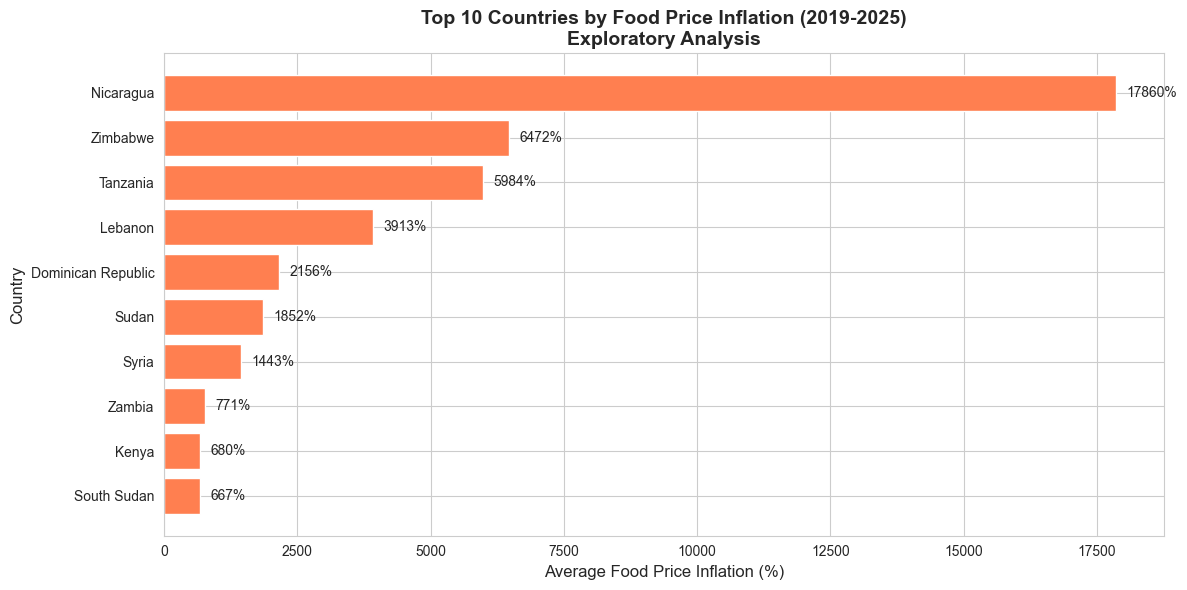

Saved: exploratory_top10_countries.png


In [15]:
# Exploratory Visualization 1: Top 10 Countries by Food Inflation
# This chart is NOT the final visualization - it shows our data exploration process

plt.figure(figsize=(12, 6))

top_10 = country_overall.head(10)

plt.barh(top_10['country'], top_10['avg_food_inflation_pct'], color='coral')
plt.xlabel('Average Food Price Inflation (%)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 10 Countries by Food Price Inflation (2019-2025)\nExploratory Analysis', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top

# Add value labels
for i, v in enumerate(top_10['avg_food_inflation_pct']):
    plt.text(v + 200, i, f'{v:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_PATH, 'exploratory_top10_countries.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Saved: exploratory_top10_countries.png")

In [16]:
# 12: Prepare Top 50 for Tableau
# Select top 50
top_50_countries = country_overall.head(50)['country'].tolist()

# Filter master data
tableau_data = master_data[master_data['country'].isin(top_50_countries)].copy()

# Category breakdown
category_totals = tableau_data.groupby(['country', 'food_category']).agg({
    'inflation_pct': 'mean'
}).reset_index()
category_totals.rename(columns={'inflation_pct': 'category_inflation_pct'}, inplace=True)

print(f"Tableau dataset: {len(tableau_data):,} rows")
print(f"Countries: {len(top_50_countries)}")
print(f"Category breakdown: {len(category_totals):,} rows")

Tableau dataset: 1,739 rows
Countries: 50
Category breakdown: 265 rows


In [17]:
# Exporting the data
# Export files
master_output = os.path.join(PROCESSED_DATA_PATH, "food_crisis_master.csv")
master_data.to_csv(master_output, index=False)
print(f"Exported: food_crisis_master.csv")

country_summary_output = os.path.join(PROCESSED_DATA_PATH, "country_summary_all.csv")
country_overall.to_csv(country_summary_output, index=False)
print(f"Exported: country_summary_all.csv")

top50_output = os.path.join(PROCESSED_DATA_PATH, "country_summary_top50.csv")
country_overall.head(50).to_csv(top50_output, index=False)
print(f"Exported: country_summary_top50.csv")

category_output = os.path.join(PROCESSED_DATA_PATH, "category_breakdown_top50.csv")
category_totals.to_csv(category_output, index=False)
print(f"Exported: category_breakdown_top50.csv")

tableau_output = os.path.join(PROCESSED_DATA_PATH, "tableau_ready_data.csv")
tableau_data.to_csv(tableau_output, index=False)
print(f"Exported: tableau_ready_data.csv")

print("\nAll files exported successfully to Processed_Data folder")

Exported: food_crisis_master.csv
Exported: country_summary_all.csv
Exported: country_summary_top50.csv
Exported: category_breakdown_top50.csv
Exported: tableau_ready_data.csv

All files exported successfully to Processed_Data folder


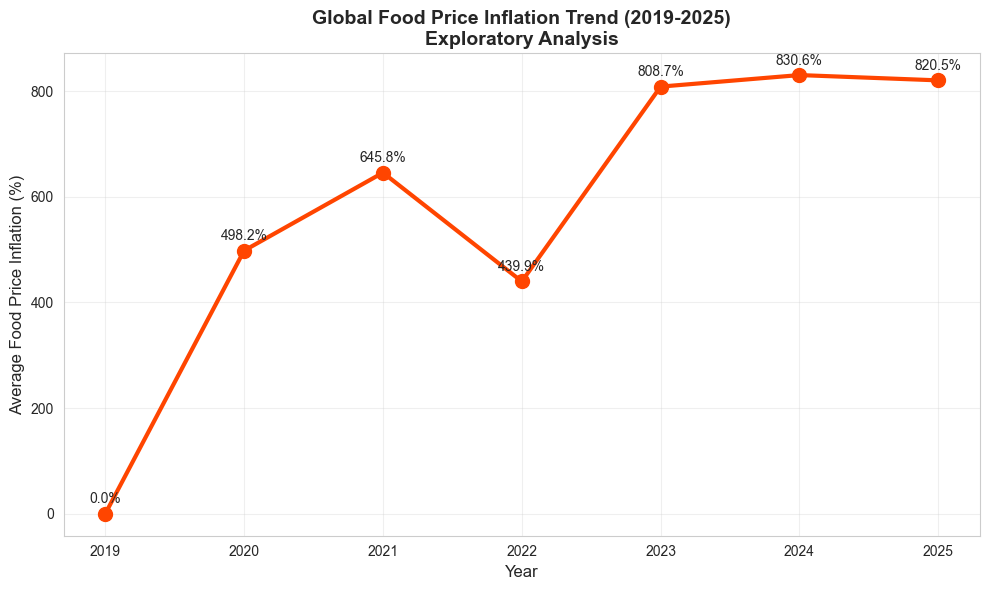

Saved: exploratory_yearly_trend.png


In [18]:
# Exploratory Visualization 2: Inflation Trends Over Time
# Shows how food inflation evolved from 2019-2025

# Calculate average inflation by year across all countries
yearly_trend = country_year_summary.groupby('year').agg({
    'inflation_pct': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))

plt.plot(yearly_trend['year'], yearly_trend['inflation_pct'], 
         marker='o', linewidth=3, markersize=10, color='orangered')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Food Price Inflation (%)', fontsize=12)
plt.title('Global Food Price Inflation Trend (2019-2025)\nExploratory Analysis', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for x, y in zip(yearly_trend['year'], yearly_trend['inflation_pct']):
    plt.text(x, y + 20, f'{y:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_PATH, 'exploratory_yearly_trend.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Saved: exploratory_yearly_trend.png")

In [19]:
# Summary Statistics
print("TOP 10 COUNTRIES BY FOOD INFLATION:")
print(country_overall.head(10)[['country', 'avg_food_inflation_pct', 'avg_gdp_per_capita']])

print(f"\nTotal raw records: {len(wfp_combined):,}")
print(f"Countries analyzed: {len(country_overall)}")
print(f"Average global food inflation: {country_overall['avg_food_inflation_pct'].mean():.2f}%")
print(f"Median food inflation: {country_overall['avg_food_inflation_pct'].median():.2f}%")
print(f"Highest: {country_overall['avg_food_inflation_pct'].max():.2f}%")
print(f"Lowest: {country_overall['avg_food_inflation_pct'].min():.2f}%")

TOP 10 COUNTRIES BY FOOD INFLATION:
               country  avg_food_inflation_pct  avg_gdp_per_capita
59           Nicaragua            17860.202586         2302.554762
89            Zimbabwe             6471.511015         1998.624062
79            Tanzania             5983.972569         1159.780416
45             Lebanon             3912.677440         5128.905798
22  Dominican Republic             2156.104704         8487.389847
76               Sudan             1852.116186          805.454946
77               Syria             1443.333575                 NaN
88              Zambia              770.587961         1225.121144
42               Kenya              679.505567         2036.238557
74         South Sudan              667.317597                 NaN

Total raw records: 2,013,445
Countries analyzed: 90
Average global food inflation: 501.52%
Median food inflation: 33.15%
Highest: 17860.20%
Lowest: -79.99%


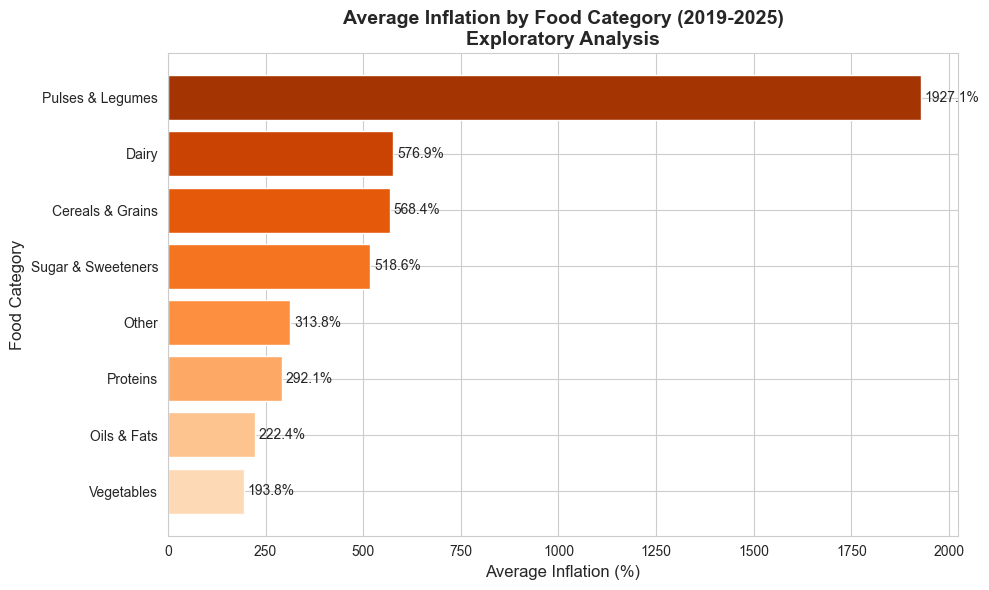

Saved: exploratory_category_inflation.png


In [20]:
# Exploratory Visualization 3: Which Food Categories Have Highest Inflation?

# Calculate average inflation by food category across all countries
category_inflation = master_data.groupby('food_category').agg({
    'inflation_pct': 'mean'
}).reset_index()
category_inflation = category_inflation.sort_values('inflation_pct', ascending=True)

plt.figure(figsize=(10, 6))

colors = plt.cm.Oranges(range(50, 250, int(200/len(category_inflation))))
plt.barh(category_inflation['food_category'], category_inflation['inflation_pct'], 
         color=colors)

plt.xlabel('Average Inflation (%)', fontsize=12)
plt.ylabel('Food Category', fontsize=12)
plt.title('Average Inflation by Food Category (2019-2025)\nExploratory Analysis', 
          fontsize=14, fontweight='bold')

# Add value labels
for i, v in enumerate(category_inflation['inflation_pct']):
    plt.text(v + 10, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_PATH, 'exploratory_category_inflation.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Saved: exploratory_category_inflation.png")